In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

## Task 1: One-Sample t-Test

**Scenario:** A coffee-shop chain claims that the average wait time at their stores is 4.0 minutes. You have collected wait times (in minutes) from a random sample of 35 visits.

### 1. State the Null and Alternative Hypotheses

- **Null Hypothesis ($H_0$):** $\mu = 4.0$ (The average wait time is 4.0 minutes)
- **Alternative Hypothesis ($H_1$):** $\mu \neq 4.0$ (The average wait time is not 4.0 minutes)

In [ ]:
# Generate the sample data
wait_times = np.random.normal(loc=4.3, scale=1.2, size=35)

# Run one-sample t-test
t_stat, p_val = st.ttest_1samp(wait_times, popmean=4.0)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

### 2. Decision and Interpretation

- **Decision:** Since the p-value (0.4614) is greater than $\alpha = 0.05$, we **fail to reject the null hypothesis**.
- **Interpretation:** There is not sufficient evidence to suggest that the average wait time differs from 4.0 minutes.

## Task 2: Independent Two-Sample t-Test

**Scenario:** An e-commerce company ran an A/B test on its checkout page. Group A (control, n = 50) saw the old design; Group B (treatment, n = 50) saw a streamlined design. The metric is order value in euros.

### 1. State the Null and Alternative Hypotheses

- **Null Hypothesis ($H_0$):** $\mu_A = \mu_B$ (The means are equal)
- **Alternative Hypothesis ($H_1$):** $\mu_A \neq \mu_B$ (The means are not equal)

In [ ]:
# Generate data for both groups
group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50)

# Check equal-variance assumption
var_a = np.var(group_a, ddof=1)
var_b = np.var(group_b, ddof=1)
lev_stat, lev_p = st.levene(group_a, group_b)

print(f"Variance A: {var_a:.4f}")
print(f"Variance B: {var_b:.4f}")
print(f"Levene's test p-value: {lev_p:.4f}")

# Choose test based on Levene result (p > 0.05 suggests equal variance)
equal_var_assumption = lev_p > 0.05
t_stat, t_p = st.ttest_ind(group_a, group_b, equal_var=equal_var_assumption)

print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value: {t_p:.4f}")

### 2. Decision and Interpretation

- **Decision:** Since the Levene p-value (0.7096) is $> 0.05$, we assume equal variances. In the subsequent t-test, the p-value (0.0260) is **less than $\alpha = 0.05$**, so we **reject the null hypothesis**.
- **Interpretation:** There is sufficient evidence to suggest that the average order value differs significantly between the two page designs.

## Task 3: Paired t-Test

**Scenario:** A company measures employee productivity scores before and after a new workflow tool is introduced. The same 30 employees are measured at both time points.

### 1. State the Null and Alternative Hypotheses

- **Null Hypothesis ($H_0$):** $\mu_{\text{diff}} = 0$ (There is no difference in productivity)
- **Alternative Hypothesis ($H_1$):** $\mu_{\text{diff}} \neq 0$ (There is a significant difference in productivity)

**Justification:** A two-tailed test is chosen to detect any change in productivity, whether it increases or decreases, as we want to know if the tool has an effect.

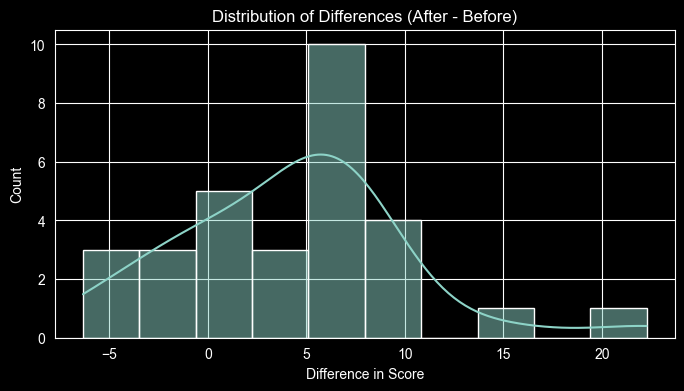

t-statistic: 4.0141
p-value: 0.0004


In [5]:
# Generate paired data
before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30)

# Compute differences
differences = after - before

# Inspect differences
plt.figure(figsize=(8, 4))
sns.histplot(differences, kde=True, bins=10)
plt.title("Distribution of Differences (After - Before)")
plt.xlabel("Difference in Score")
plt.show()

# Run paired t-test
t_stat, p_val = st.ttest_rel(after, before)

print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_val:.4f}")

### 2. Decision and Interpretation
Decision:
-Since the p-value (0.0004) is less than $\alpha = 0.05$, we reject the null hypothesis ($H_0$).
Interpretation:
-There is sufficient statistical evidence to conclude that there is a significant difference between the scores before and after the intervention. The positive t-statistic (4.0141) and the distribution of differences indicate that scores improved significantly.